# Optuna Data Inspector - Model Complexity vs Performance

Analyze the optuna-n64 tuning study to visualize model complexity, performance trade-offs, and hyperparameter importance.

In [1]:
import os
import sys
import logging
import math
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sys.path.append("/users/stevensonb/Research/tools/deepsphere-cosmo-tf2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.importance import FanovaImportanceEvaluator
import tensorflow as tf

tf.get_logger().setLevel(logging.ERROR)

from mlpng import Core
from mlpng.optuna_trainer import TunableEncoderFnlModel
from mlpng.utils import setup_logging

setup_logging("mlpng.notebook", level=logging.INFO)
logger = logging.getLogger("mlpng.notebook")

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

print("Imports successful")

Imports successful


In [2]:
# Initialize Core with nside 64 and all shapes
core = Core(["./settings/n64.json", "--shapes", "all", "--nsims", "10000"])

print(f"Configuration:")
print(f"  nside: {core.nside}")
print(f"  npix:  {core.npix}")
print(f"  npols: {core.npols}")
print(f"  shapes: {core.shapes}")
print(f"  n_outputs: {len(core.shapes)}")

25-Jan-26 10:47:31 - mlpng.core - INFO - Loading settings from file './settings/n64.json'
Configuration:
  nside: 64
  npix:  49152
  npols: 1
  shapes: ['local', 'equilateral', 'orthogonal']
  n_outputs: 3
Configuration:
  nside: 64
  npix:  49152
  npols: 1
  shapes: ['local', 'equilateral', 'orthogonal']
  n_outputs: 3


In [3]:
# Load optuna study from database
storage_file = Path("./data/tuner") / f"optuna-n{core.nside}-2.db"
storage_url = f"sqlite:///{storage_file.absolute()}"

study_name = f"neo-mse-n{core.nside}-{('_').join(core.shapes)}"
print(f"Loading study: {study_name}")
print(f"Storage: {storage_url}")

study = optuna.create_study(
    direction="minimize",
    study_name=study_name,
    storage=storage_url,
    load_if_exists=True,
)

print(f"\nStudy loaded:")
print(f"  Number of trials: {len(study.trials)}")
print(f"  Best value: {study.best_value:.6f}")
print(f"  Best trial: {study.best_trial.number}")

Loading study: neo-mse-n64-local_equilateral_orthogonal
Storage: sqlite:////users/stevensonb/Research/MLPNG/data/tuner/optuna-n64-2.db


[I 2026-01-25 10:47:31,599] Using an existing study with name 'neo-mse-n64-local_equilateral_orthogonal' instead of creating a new one.



Study loaded:
  Number of trials: 265
  Best value: 65111.941406
  Best trial: 152


In [4]:
# Check what data is available in trials
print("\\nInspecting trial data structure:")
print("\\nBest trial attributes:")
best_trial = study.best_trial
print(f"  value: {best_trial.value}")
print(f"  params: {best_trial.params}")
print(f"  user_attrs: {best_trial.user_attrs}")
print(f"  system_attrs: {best_trial.system_attrs}")
print(f"  intermediate_values: {best_trial.intermediate_values}")
print(
    f"\\nNumber of non-empty intermediate values: {len(best_trial.intermediate_values)}"
)
if best_trial.intermediate_values:
    print(f"  Sample: {list(best_trial.intermediate_values.items())[:3]}")

\nInspecting trial data structure:
\nBest trial attributes:
  value: 65111.94140625
  params: {'pool_p': 2, 'K': 5, 'encoder_activation': 'gelu', 'head_activation': 'relu', 'pool_type': 'AVG', 'use_cosine_decay': True, 'initial_lr': 0.004804009743202004, 'decay_rate': 0.91, 'dropout_rate': 0.0, 'weight_decay': 0.00015968977124979086, 'shared_units': 64, 'dense_layers': 1, 'split_units': 32, 'head_layers': 2, 'head_dropout': 0.0}
  user_attrs: {'best_val_rmse_equilateral': 363.86248779296875, 'best_val_rmse_local': 72.06136322021484, 'best_val_rmse_orthogonal': 240.30628967285156}
  system_attrs: {'tpe:relative_params:0': '{"K": 5, "decay_rate": 0.91, "dense_layers": 1, "dropout_rate": 0.0, "encoder_activation": "gelu", "head_activation": "relu", "head_dropout": 0.0, "head_layers": 2, "initial_lr": 0.004804009743202004, "pool_p": 2, "pool_type": "AVG", "shared_units": 64, "split_units": 32, "use_cosine_decay": true, "weight_decay": 0.00015968977124979086}'}
  intermediate_values: {}
\nN

## Parameter Counting Function

In [5]:
def estimate_parameters_from_hyperparams(params, nside, npix, npols, n_outputs):
    """
    Estimate total number of parameters for a model given hyperparameters.

    Args:
        params: dict with keys pool_p, K, shared_units, dense_layers, split_units, head_layers, head_dropout
        nside: HEALPix nside parameter
        npix: number of pixels (12 * nside^2)
        npols: number of polarizations
        n_outputs: number of output shapes

    Returns:
        int: total number of trainable parameters
    """
    pool_p = params["pool_p"]
    K = params["K"]
    shared_units = params["shared_units"]
    dense_layers = params["dense_layers"]
    split_units = params["split_units"]
    head_layers = params["head_layers"]
    head_dropout = params.get("head_dropout", 0.0)

    # Calculate encoder depth
    nside_factor = 2**pool_p
    depth = int(math.log(nside, nside_factor))

    total_params = 0

    # Calculate level information
    level_nsides = [nside // (nside_factor**i) for i in range(depth + 1)]
    level_npixels = [12 * ns**2 for ns in level_nsides]

    # Channel progression: starts at npols, then increases
    channels = [npols] + [2 ** (i + 5) for i in range(depth + 1)]  # 32, 64, 128, ...

    # Encoder layers
    for level in range(depth):
        level_npix = level_npixels[level]
        in_channels = channels[level]
        out_channels = channels[level + 1]

        # HealpyChebyshev layer: each vertex has K*in*out weights
        cheby_params = level_npix * K * in_channels * out_channels
        total_params += cheby_params

        # HealpyPool: no learnable parameters

    # Flatten/bottleneck layer
    bottleneck_in = level_npixels[-1] * channels[-1]

    # Shared dense layers
    if dense_layers > 0:
        # First dense layer: bottleneck_in -> shared_units
        total_params += bottleneck_in * shared_units + shared_units  # weights + bias

        # Intermediate shared dense layers
        for _ in range(dense_layers - 1):
            total_params += shared_units * shared_units + shared_units  # weights + bias

        last_hidden = shared_units
    else:
        last_hidden = bottleneck_in

    # Split head layer
    # Shared dense layers (if any) already counted above

    # Per-shape split branches
    for _ in range(n_outputs):
        branch_in = last_hidden

        # Split branch dense layers
        for layer_idx in range(head_layers):
            total_params += branch_in * split_units + split_units  # weights + bias
            branch_in = split_units

        # Final output layer for this shape
        total_params += branch_in * 1 + 1  # weights + bias

    return total_params


print("Parameter counting function defined")

Parameter counting function defined


In [6]:
# Test parameter counting with best trial
best_params = study.best_trial.params
best_param_count = estimate_parameters_from_hyperparams(
    best_params, core.nside, core.npix, core.npols, len(core.shapes)
)

print(f"Best trial hyperparameters:")
for key, val in best_params.items():
    print(f"  {key}: {val}")

print(f"\nEstimated parameters: {best_param_count:,}")

Best trial hyperparameters:
  pool_p: 2
  K: 5
  encoder_activation: gelu
  head_activation: relu
  pool_type: AVG
  use_cosine_decay: True
  initial_lr: 0.004804009743202004
  decay_rate: 0.91
  dropout_rate: 0.0
  weight_decay: 0.00015968977124979086
  shared_units: 64
  dense_layers: 1
  split_units: 32
  head_layers: 2
  head_dropout: 0.0

Estimated parameters: 47,392,099


## Extract and Analyze Trial Data

In [7]:
# Extract data from all completed trials
trial_data = []

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        param_count = estimate_parameters_from_hyperparams(
            trial.params, core.nside, core.npix, core.npols, len(core.shapes)
        )

        row = {
            "trial_number": trial.number,
            "value": trial.value,
            "params": trial.params,
            "parameters_count": param_count,
            "pool_p": trial.params.get("pool_p", None),
            "K": trial.params.get("K", None),
            "shared_units": trial.params.get("shared_units", None),
            "dense_layers": trial.params.get("dense_layers", None),
            "split_units": trial.params.get("split_units", None),
            "head_layers": trial.params.get("head_layers", None),
            "encoder_activation": trial.params.get("encoder_activation", None),
            "head_activation": trial.params.get("head_activation", None),
            "initial_lr": trial.params.get("initial_lr", None),
            "dropout_rate": trial.params.get("dropout_rate", None),
            "head_dropout": trial.params.get("head_dropout", None),
        }

        # Add per-shape RMSE metrics if available
        for shape in core.shapes:
            rmse_key = f"best_val_rmse_{shape}"
            row[f"rmse_{shape}"] = trial.user_attrs.get(rmse_key, None)

        trial_data.append(row)

df_trials = pd.DataFrame(trial_data)
print(f"Extracted {len(df_trials)} completed trials")
print(f"\nTrial statistics:")
print(df_trials[["trial_number", "value", "parameters_count"]].describe())

# Check if per-shape RMSE data is available
rmse_cols = [col for col in df_trials.columns if col.startswith("rmse_")]
if rmse_cols:
    print(f"\nPer-shape RMSE metrics available:")
    for col in rmse_cols:
        non_null = df_trials[col].notna().sum()
        print(f"  {col}: {non_null}/{len(df_trials)} trials")
else:
    print(
        "\nNote: Per-shape RMSE metrics not yet available (require new training runs)"
    )

Extracted 255 completed trials

Trial statistics:
       trial_number          value  parameters_count
count    255.000000     255.000000      2.550000e+02
mean     127.015686  110041.811075      1.018152e+08
std       73.783252   78848.988995      1.639338e+08
min        0.000000   65111.941406      1.888359e+07
25%       63.500000   68763.675781      2.873389e+07
50%      127.000000   74231.203125      4.738740e+07
75%      190.500000  108491.183594      4.760284e+07
max      255.000000  551829.000000      6.417539e+08

Per-shape RMSE metrics available:
  rmse_local: 255/255 trials
  rmse_equilateral: 255/255 trials
  rmse_orthogonal: 255/255 trials


## Trial Progression Visualization

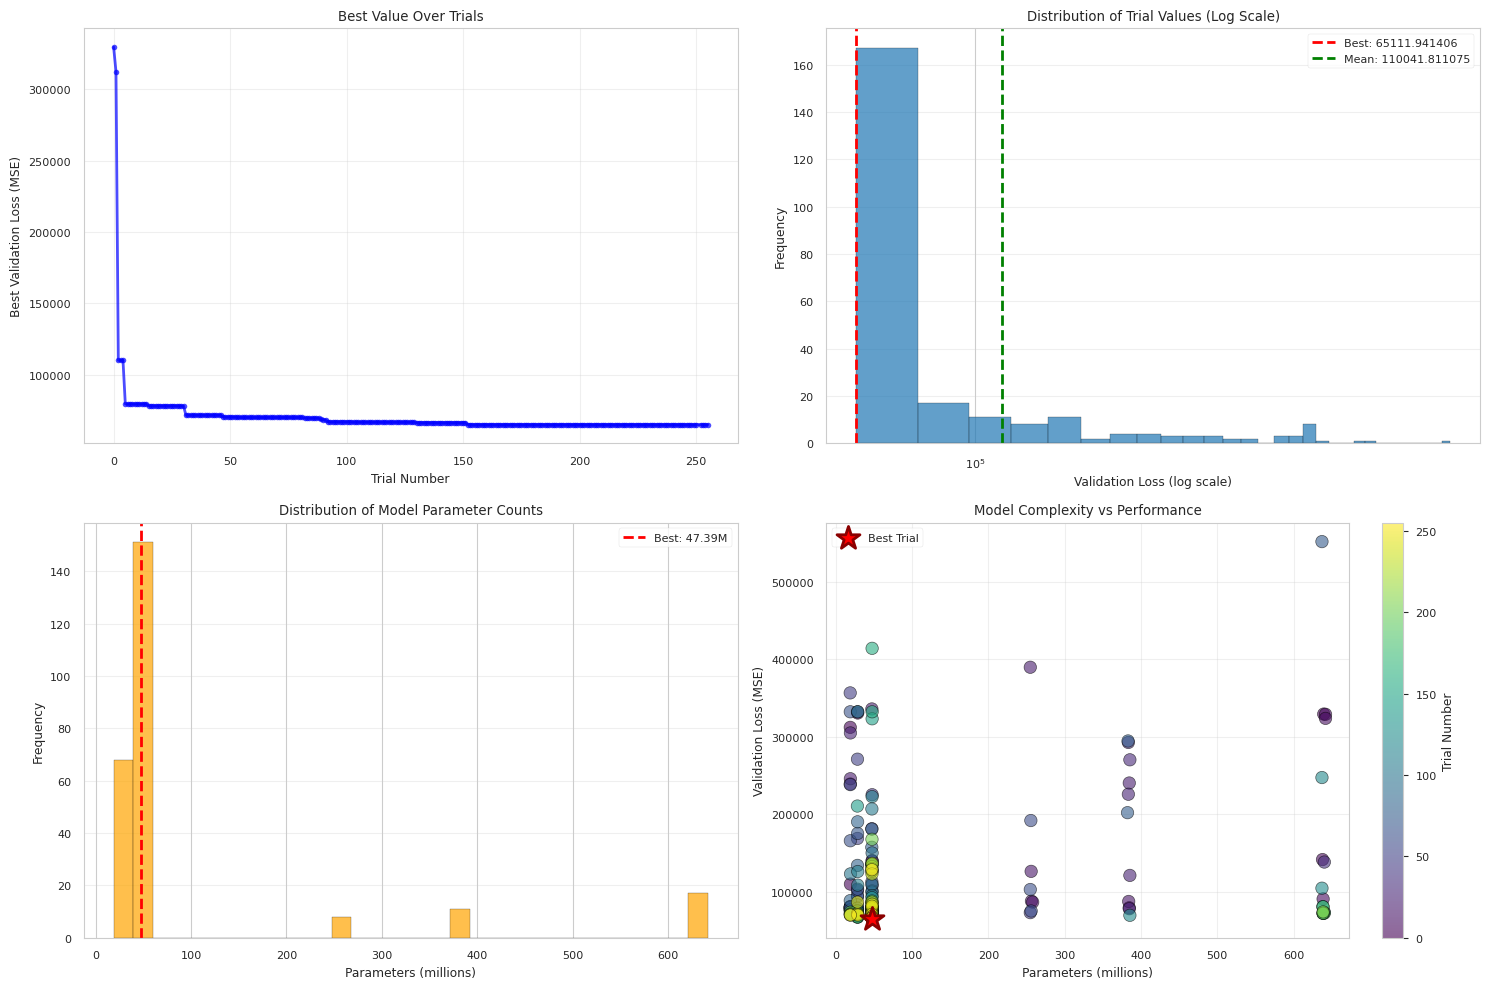


Optimization Summary:
  Total trials: 255
  Best validation loss: 65111.941406
  Best trial number: 152
  Parameter range: 18.88M - 641.75M


In [8]:
# Plot trial progression
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Best value over trials
best_values = [min(df_trials["value"].iloc[: i + 1]) for i in range(len(df_trials))]
axes[0, 0].plot(
    df_trials["trial_number"], best_values, "b-o", linewidth=2, markersize=4, alpha=0.7
)
axes[0, 0].set_xlabel("Trial Number")
axes[0, 0].set_ylabel("Best Validation Loss (MSE)")
axes[0, 0].set_title("Best Value Over Trials")
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution of trial values (log x-scale)
axes[0, 1].hist(df_trials["value"], bins=30, edgecolor="black", alpha=0.7)
axes[0, 1].axvline(
    study.best_value,
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Best: {study.best_value:.6f}",
)
axes[0, 1].axvline(
    df_trials["value"].mean(),
    color="g",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df_trials['value'].mean():.6f}",
)
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("Validation Loss (log scale)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of Trial Values (Log Scale)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis="y")

# 3. Parameters count distribution
axes[1, 0].hist(
    df_trials["parameters_count"] / 1e6,
    bins=30,
    edgecolor="black",
    alpha=0.7,
    color="orange",
)
axes[1, 0].axvline(
    best_param_count / 1e6,
    color="r",
    linestyle="--",
    linewidth=2,
    label=f"Best: {best_param_count/1e6:.2f}M",
)
axes[1, 0].set_xlabel("Parameters (millions)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Distribution of Model Parameter Counts")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis="y")

# 4. Trial value vs parameters count
scatter = axes[1, 1].scatter(
    df_trials["parameters_count"] / 1e6,
    df_trials["value"],
    c=df_trials["trial_number"],
    cmap="viridis",
    s=80,
    alpha=0.6,
    edgecolors="black",
    linewidth=0.5,
)
axes[1, 1].scatter(
    best_param_count / 1e6,
    study.best_value,
    color="red",
    s=300,
    marker="*",
    edgecolors="darkred",
    linewidth=2,
    label="Best Trial",
    zorder=5,
)
axes[1, 1].set_xlabel("Parameters (millions)")
axes[1, 1].set_ylabel("Validation Loss (MSE)")
axes[1, 1].set_title("Model Complexity vs Performance")
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label("Trial Number")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"  Total trials: {len(df_trials)}")
print(f"  Best validation loss: {study.best_value:.6f}")
print(f"  Best trial number: {study.best_trial.number}")
print(
    f"  Parameter range: {df_trials['parameters_count'].min()/1e6:.2f}M - {df_trials['parameters_count'].max()/1e6:.2f}M"
)

## Hyperparameter Importance Analysis

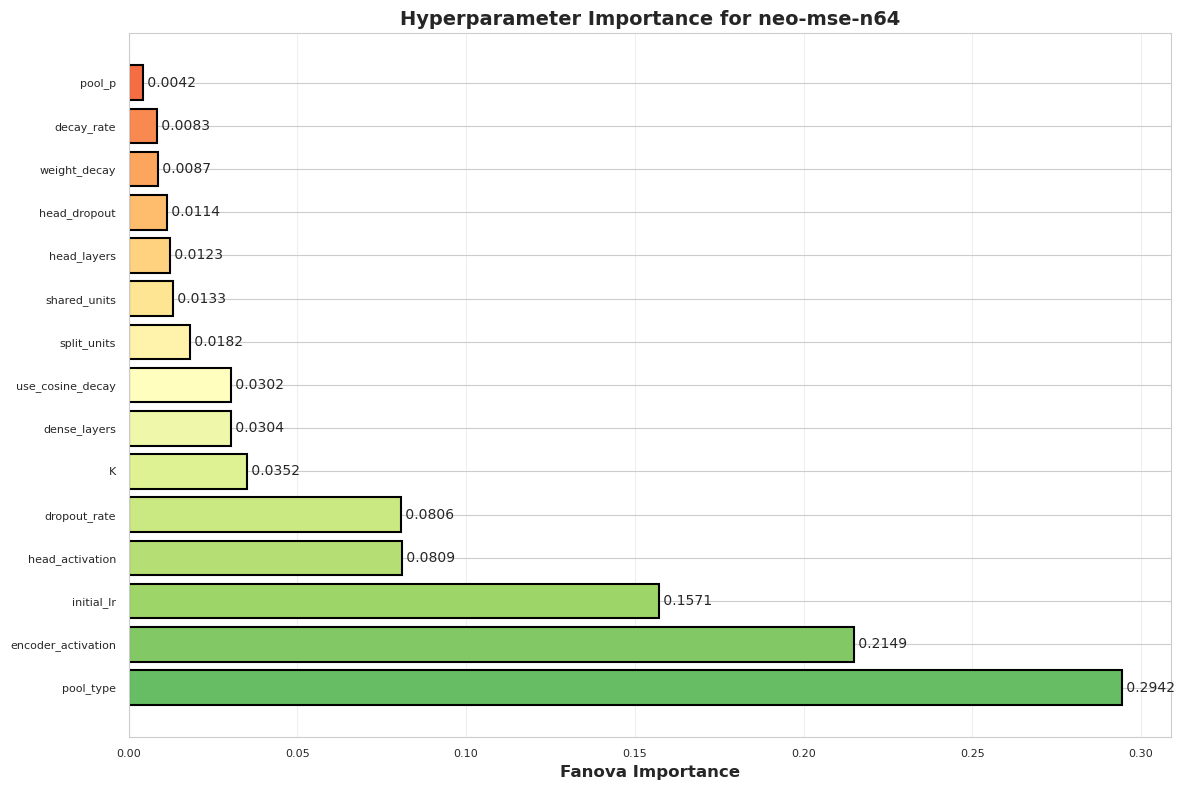


Hyperparameter Importance (sorted):
pool_type                : 0.294236
encoder_activation       : 0.214892
initial_lr               : 0.157123
head_activation          : 0.080887
dropout_rate             : 0.080631
K                        : 0.035218
dense_layers             : 0.030370
use_cosine_decay         : 0.030230
split_units              : 0.018204
shared_units             : 0.013271
head_layers              : 0.012254
head_dropout             : 0.011447
weight_decay             : 0.008719
decay_rate               : 0.008274
pool_p                   : 0.004243


In [9]:
# Compute hyperparameter importances
try:
    evaluator = FanovaImportanceEvaluator()
    importances = optuna.importance.get_param_importances(study, evaluator=evaluator)

    # Sort by importance
    sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)

    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 8))

    param_names = [name for name, _ in sorted_importances]
    importance_values = [imp for _, imp in sorted_importances]

    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(param_names)))
    bars = ax.barh(
        param_names, importance_values, color=colors, edgecolor="black", linewidth=1.5
    )

    ax.set_xlabel("Fanova Importance", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Hyperparameter Importance for neo-mse-n{core.nside}",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, axis="x")

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, importance_values)):
        ax.text(val, i, f" {val:.4f}", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\nHyperparameter Importance (sorted):")
    print("=" * 50)
    for param_name, importance in sorted_importances:
        print(f"{param_name:25s}: {importance:.6f}")
    print("=" * 50)

except Exception as e:
    print(f"Error computing importance: {e}")
    print("Proceeding without importance analysis")

## Detailed Complexity vs Performance Analysis

In [10]:
# Compute Pareto frontier (non-dominated solutions)
def compute_pareto_frontier(df, x_col, y_col, y_is_minimize=True):
    """
    Compute Pareto frontier for bi-objective optimization.
    Returns indices of non-dominated solutions.
    """
    is_frontier = np.ones(len(df), dtype=bool)

    for i in range(len(df)):
        for j in range(len(df)):
            if i == j:
                continue

            # j dominates i if j has lower x and lower y (for minimization)
            if y_is_minimize:
                if (
                    df[x_col].iloc[j] <= df[x_col].iloc[i]
                    and df[y_col].iloc[j] <= df[y_col].iloc[i]
                ):
                    if (
                        df[x_col].iloc[j] < df[x_col].iloc[i]
                        or df[y_col].iloc[j] < df[y_col].iloc[i]
                    ):
                        is_frontier[i] = False
                        break

    return is_frontier


pareto_mask = compute_pareto_frontier(df_trials, "parameters_count", "value")
df_pareto = df_trials[pareto_mask]

print(f"Pareto frontier size: {len(df_pareto)} / {len(df_trials)} trials")
print(f"\nPareto frontier trials:")
print(df_pareto[["trial_number", "parameters_count", "value"]].to_string())

Pareto frontier size: 13 / 255 trials

Pareto frontier trials:
     trial_number  parameters_count         value
31             31          18972803  71698.257812
35             35          18883587  77671.429688
98             98          28459107  69472.281250
127           127          28508419  67385.531250
136           136          28459923  69189.023438
152           152          47392099  65111.941406
206           206          47286947  66405.562500
216           216          47285891  67225.984375
220           220          47386579  65604.148438
231           231          47391555  65368.382812
250           250          47293859  65853.765625
251           252          47287523  66205.226562
253           254          19079187  70119.445312


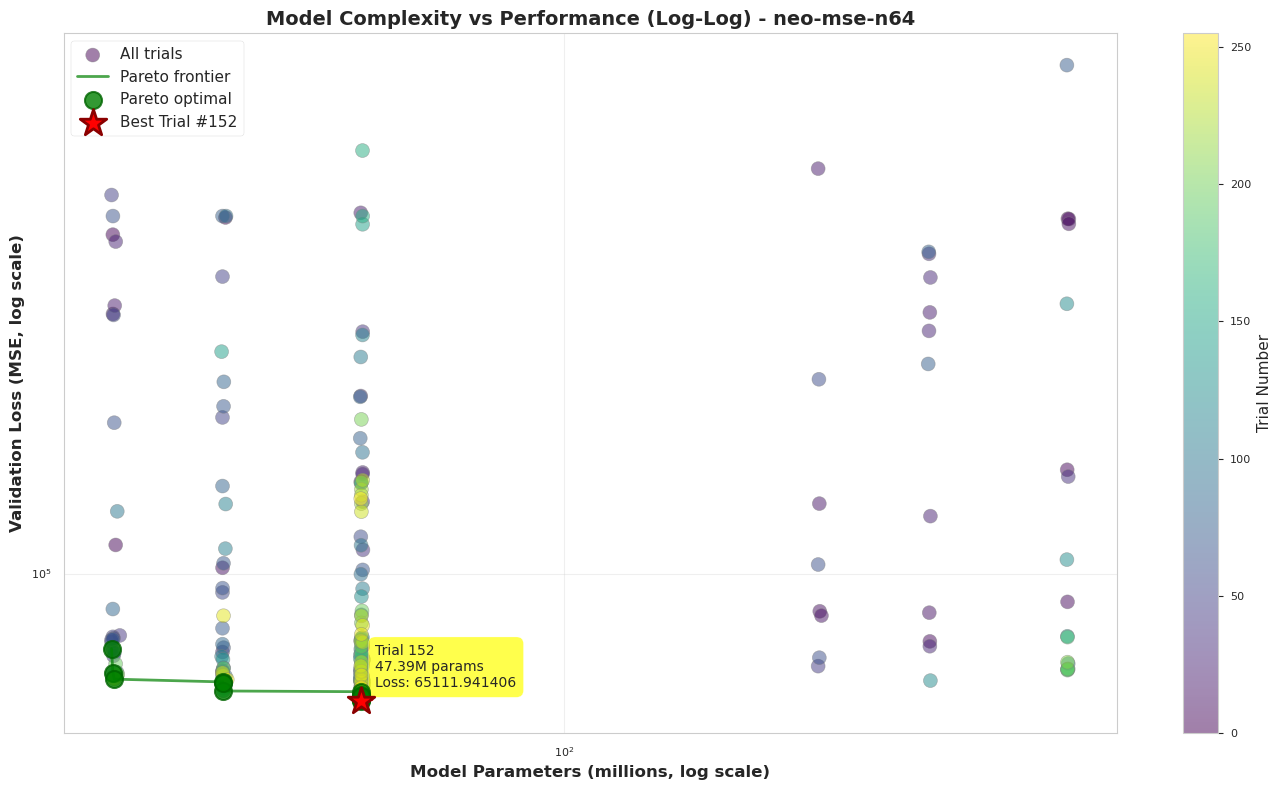

In [11]:
# Detailed scatter plot with Pareto frontier
fig, ax = plt.subplots(figsize=(14, 8))

# Plot all trials
scatter = ax.scatter(
    df_trials["parameters_count"] / 1e6,
    df_trials["value"],
    c=df_trials["trial_number"],
    cmap="viridis",
    s=100,
    alpha=0.5,
    edgecolors="gray",
    linewidth=0.5,
    label="All trials",
)

# Plot Pareto frontier
df_pareto_sorted = df_pareto.sort_values("parameters_count")
ax.plot(
    df_pareto_sorted["parameters_count"] / 1e6,
    df_pareto_sorted["value"],
    "g-",
    linewidth=2,
    alpha=0.7,
    label="Pareto frontier",
)
ax.scatter(
    df_pareto["parameters_count"] / 1e6,
    df_pareto["value"],
    color="green",
    s=150,
    alpha=0.8,
    edgecolors="darkgreen",
    linewidth=1.5,
    zorder=4,
    label="Pareto optimal",
)

# Highlight best trial
ax.scatter(
    best_param_count / 1e6,
    study.best_value,
    color="red",
    s=400,
    marker="*",
    edgecolors="darkred",
    linewidth=2,
    label=f"Best Trial #{study.best_trial.number}",
    zorder=5,
)

# Annotate best trial
ax.annotate(
    f"Trial {study.best_trial.number}\n{best_param_count/1e6:.2f}M params\nLoss: {study.best_value:.6f}",
    xy=(best_param_count / 1e6, study.best_value),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", color="red", lw=1.5),
)

ax.set_xlabel("Model Parameters (millions, log scale)", fontsize=12, fontweight="bold")
ax.set_ylabel("Validation Loss (MSE, log scale)", fontsize=12, fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(
    f"Model Complexity vs Performance (Log-Log) - neo-mse-n{core.nside}",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="best", fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Trial Number", fontsize=11)

plt.tight_layout()
plt.show()

## Best Model Analysis

In [12]:
# Display best model details
print("\n" + "=" * 80)
print(f"BEST MODEL ANALYSIS - Trial {study.best_trial.number}")
print("=" * 80)

print(f"\nObjective Value: {study.best_value:.6f}")
print(f"Estimated Parameters: {best_param_count:,}")
print(f"Parameter Size: {best_param_count / 1e6:.2f} Million")

print(f"\nBest Hyperparameters:")
print("-" * 80)

# Architecture parameters
print("\n[ARCHITECTURE]")
print(f"  pool_p:              {best_params['pool_p']}")
print(f"  K (Chebyshev order): {best_params['K']}")
print(f"  encoder_activation:  {best_params['encoder_activation']}")
print(f"  head_activation:     {best_params['head_activation']}")
print(f"  pool_type:           {best_params['pool_type']}")

# Head configuration
print("\n[HEAD CONFIGURATION]")
print(f"  shared_units:        {best_params['shared_units']}")
print(f"  dense_layers:        {best_params['dense_layers']}")
print(f"  split_units:         {best_params['split_units']}")
print(f"  head_layers:         {best_params['head_layers']}")
print(f"  head_dropout:        {best_params['head_dropout']:.2f}")

# Regularization & optimization
print("\n[REGULARIZATION & OPTIMIZATION]")
print(f"  dropout_rate:        {best_params['dropout_rate']:.2f}")
print(f"  weight_decay:        {best_params['weight_decay']:.2e}")
print(f"  use_cosine_decay:    {best_params['use_cosine_decay']}")
print(f"  initial_lr:          {best_params['initial_lr']:.2e}")
print(f"  decay_rate:          {best_params['decay_rate']:.3f}")

print("\n" + "=" * 80)


BEST MODEL ANALYSIS - Trial 152

Objective Value: 65111.941406
Estimated Parameters: 47,392,099
Parameter Size: 47.39 Million

Best Hyperparameters:
--------------------------------------------------------------------------------

[ARCHITECTURE]
  pool_p:              2
  K (Chebyshev order): 5
  encoder_activation:  gelu
  head_activation:     relu
  pool_type:           AVG

[HEAD CONFIGURATION]
  shared_units:        64
  dense_layers:        1
  split_units:         32
  head_layers:         2
  head_dropout:        0.00

[REGULARIZATION & OPTIMIZATION]
  dropout_rate:        0.00
  weight_decay:        1.60e-04
  use_cosine_decay:    True
  initial_lr:          4.80e-03
  decay_rate:          0.910



In [13]:
# Comparison with other top trials
print("\nTop 10 Trials by Validation Loss:")
print("=" * 100)

top_trials = df_trials.nsmallest(10, "value")

for idx, row in top_trials.iterrows():
    marker = "***" if row["trial_number"] == study.best_trial.number else "   "
    print(
        f"{marker} Trial {row['trial_number']:3d} | Loss: {row['value']:.6f} | Params: {row['parameters_count']/1e6:7.2f}M | pool_p={row['pool_p']} K={row['K']} shared={row['shared_units']} split={row['split_units']}"
    )

print("=" * 100)
print("*** indicates best trial")


Top 10 Trials by Validation Loss:
*** Trial 152 | Loss: 65111.941406 | Params:   47.39M | pool_p=2 K=5 shared=64 split=32
    Trial 231 | Loss: 65368.382812 | Params:   47.39M | pool_p=2 K=5 shared=64 split=16
    Trial 220 | Loss: 65604.148438 | Params:   47.39M | pool_p=2 K=5 shared=64 split=16
    Trial 250 | Loss: 65853.765625 | Params:   47.29M | pool_p=2 K=5 shared=32 split=32
    Trial 172 | Loss: 66026.453125 | Params:   47.39M | pool_p=2 K=5 shared=64 split=32
    Trial 195 | Loss: 66125.351562 | Params:   47.39M | pool_p=2 K=5 shared=64 split=16
    Trial 237 | Loss: 66153.539062 | Params:   47.39M | pool_p=2 K=5 shared=64 split=16
    Trial 199 | Loss: 66191.835938 | Params:   47.40M | pool_p=2 K=5 shared=64 split=32
    Trial 252 | Loss: 66205.226562 | Params:   47.29M | pool_p=2 K=5 shared=32 split=32
    Trial 242 | Loss: 66252.546875 | Params:   47.60M | pool_p=2 K=5 shared=128 split=16
*** indicates best trial


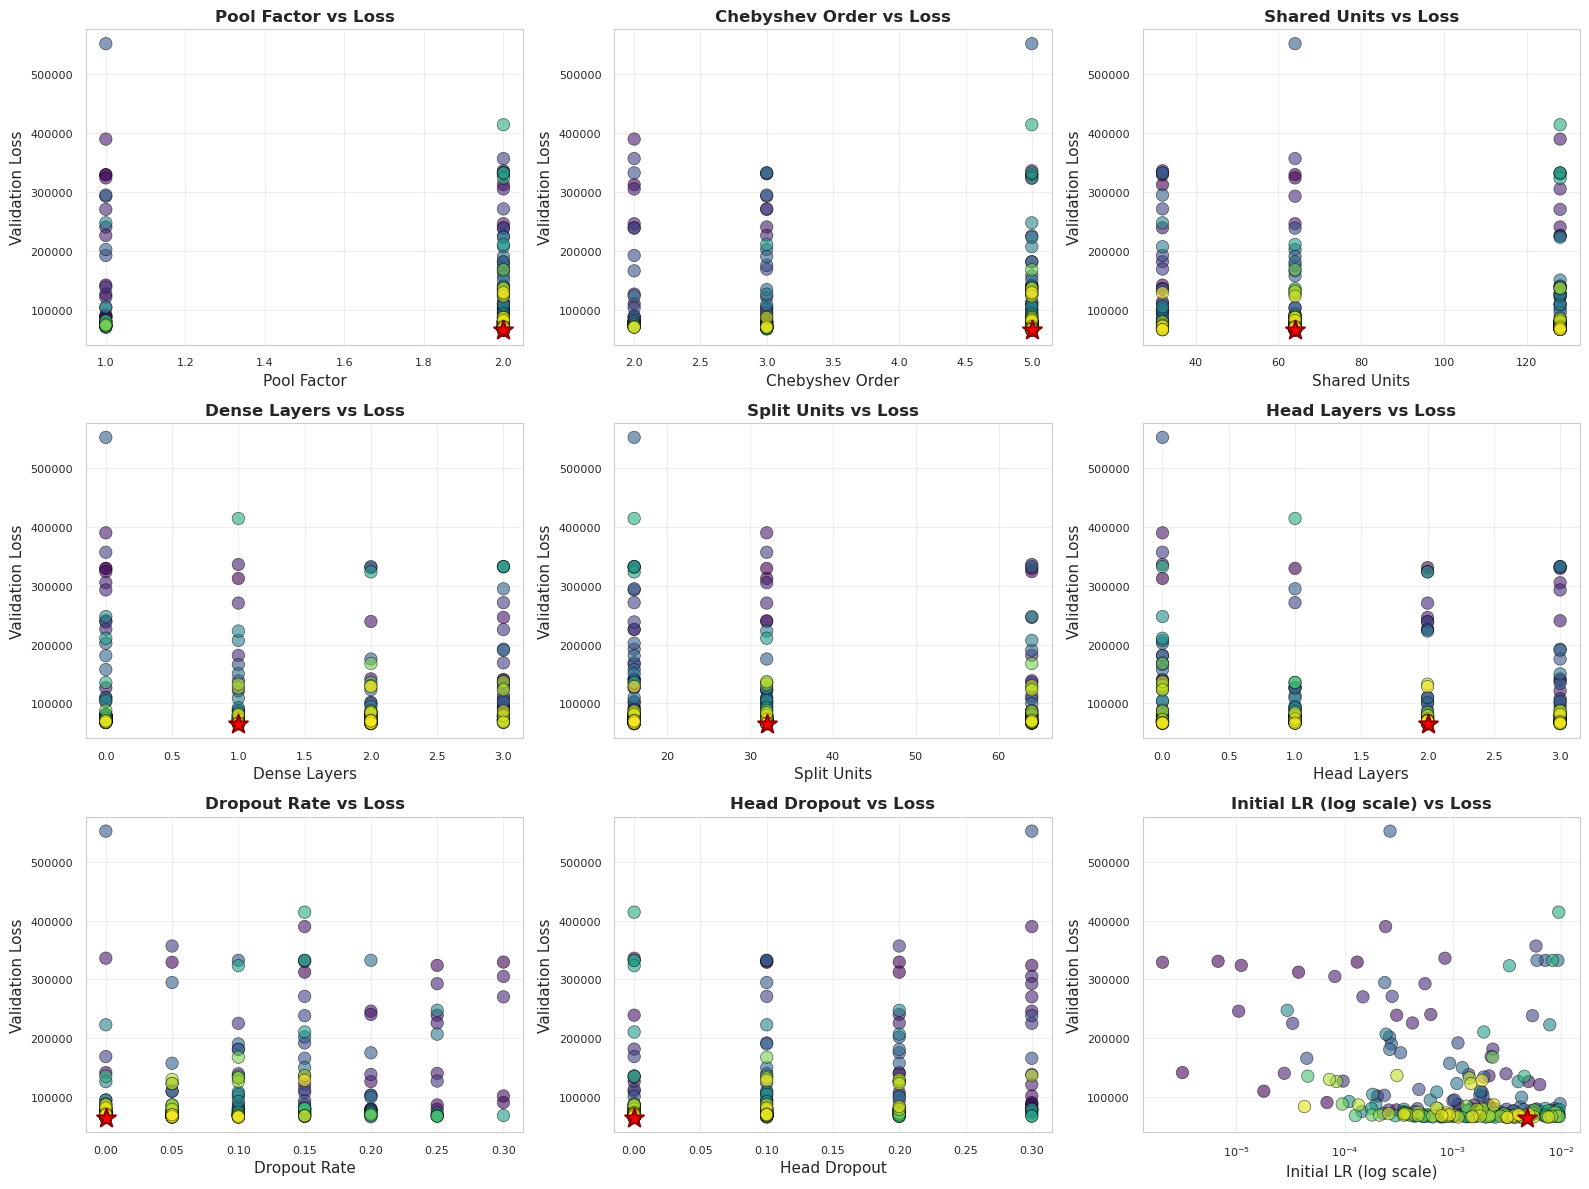

Hyperparameter value distribution plots generated


In [14]:
# Hyperparameter value distributions across trials
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

params_to_plot = [
    ("pool_p", "Pool Factor"),
    ("K", "Chebyshev Order"),
    ("shared_units", "Shared Units"),
    ("dense_layers", "Dense Layers"),
    ("split_units", "Split Units"),
    ("head_layers", "Head Layers"),
    ("dropout_rate", "Dropout Rate"),
    ("head_dropout", "Head Dropout"),
    ("initial_lr", "Initial LR (log scale)"),
]

for ax_idx, (param_name, param_label) in enumerate(params_to_plot):
    ax = axes[ax_idx]

    # Color by trial value (loss)
    scatter = ax.scatter(
        df_trials[param_name],
        df_trials["value"],
        c=df_trials["trial_number"],
        cmap="viridis",
        s=80,
        alpha=0.6,
        edgecolors="black",
        linewidth=0.5,
    )

    # Highlight best
    ax.scatter(
        best_params[param_name],
        study.best_value,
        color="red",
        s=200,
        marker="*",
        edgecolors="darkred",
        linewidth=1.5,
        zorder=5,
    )

    ax.set_xlabel(param_label, fontsize=11)
    ax.set_ylabel("Validation Loss", fontsize=11)
    ax.set_title(f"{param_label} vs Loss", fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)

    if param_name == "initial_lr":
        ax.set_xscale("log")

plt.tight_layout()
plt.show()

print("Hyperparameter value distribution plots generated")

In [15]:
# Summary statistics
print("\n" + "=" * 80)
print("OPTIMIZATION SUMMARY STATISTICS")
print("=" * 80)

print(f"\nDataset Configuration:")
print(f"  nside: {core.nside}")
print(f"  npix: {core.npix}")
print(f"  shapes: {core.shapes}")
print(f"  n_outputs: {len(core.shapes)}")

print(f"\nOptimization Results:")
print(f"  Total trials: {len(df_trials)}")
print(f"  Completed trials: {len(df_trials)}")
print(f"  Best value: {study.best_value:.6f}")
print(f"  Mean value: {df_trials['value'].mean():.6f}")
print(f"  Median value: {df_trials['value'].median():.6f}")
print(f"  Std dev: {df_trials['value'].std():.6f}")

print(f"\nModel Complexity:")
print(f"  Best model parameters: {best_param_count:,}")
print(f"  Min parameters: {df_trials['parameters_count'].min():,}")
print(f"  Max parameters: {df_trials['parameters_count'].max():,}")
print(f"  Mean parameters: {df_trials['parameters_count'].mean():,.0f}")
print(f"  Median parameters: {df_trials['parameters_count'].median():,.0f}")

print(f"\nPareto Frontier:")
print(f"  Frontier size: {len(df_pareto)} trials")
print(f"  Coverage: {100*len(df_pareto)/len(df_trials):.1f}% of trials")
print(f"  Min frontier parameters: {df_pareto['parameters_count'].min()/1e6:.2f}M")
print(f"  Max frontier parameters: {df_pareto['parameters_count'].max()/1e6:.2f}M")
print(f"  Min frontier loss: {df_pareto['value'].min():.6f}")
print(f"  Max frontier loss: {df_pareto['value'].max():.6f}")

print("\n" + "=" * 80)


OPTIMIZATION SUMMARY STATISTICS

Dataset Configuration:
  nside: 64
  npix: 49152
  shapes: ['local', 'equilateral', 'orthogonal']
  n_outputs: 3

Optimization Results:
  Total trials: 255
  Completed trials: 255
  Best value: 65111.941406
  Mean value: 110041.811075
  Median value: 74231.203125
  Std dev: 78848.988995

Model Complexity:
  Best model parameters: 47,392,099
  Min parameters: 18,883,587
  Max parameters: 641,753,859
  Mean parameters: 101,815,164
  Median parameters: 47,387,395

Pareto Frontier:
  Frontier size: 13 trials
  Coverage: 5.1% of trials
  Min frontier parameters: 18.88M
  Max frontier parameters: 47.39M
  Min frontier loss: 65111.941406
  Max frontier loss: 77671.429688



In [ ]:
# Find best model that does not surpass fisher limit based on best val
from mlpng.utils import get_data

print("\n" + "=" * 80)
print("BEST MODEL CLOSEST TO FISHER LIMIT (NOT SURPASSING)")
print("=" * 80)

# Get fisher information for each shape from the data file
fisher_limits = {}
lensed = "lensed"  # or "unlensed" depending on your data
try:
    for shape in core.shapes:
        fisher = get_data(core.file, f"fisher/{lensed}/{shape}", 0)
        std_dev = np.sqrt(1 / fisher)
        fisher_limits[shape] = std_dev
        print(f"\nFisher limit for {shape}: {std_dev:.6f}")
except Exception as e:
    print(f"Warning: Could not load fisher information: {e}")
    fisher_limits = {}

if fisher_limits:
    # Define priority order for shapes (highest to lowest priority)
    priority_order = ["equilateral", "orthogonal", "local"]

    # Calculate a composite score for each trial
    # Score prioritizes: (1) being above limit, (2) being close to it
    # Lower score (excess closer to 0 from above) is better
    scores = []
    valid_trials = []

    for idx, row in df_trials.iterrows():
        composite_score = []
        is_valid = True

        for shape in priority_order:
            rmse_col = f"rmse_{shape}"
            fisher_limit = fisher_limits.get(shape)

            if rmse_col in df_trials.columns and fisher_limit is not None:
                rmse_val = row[rmse_col]
                if not pd.isna(rmse_val):
                    # Excess over limit: negative if under, positive if over
                    excess = rmse_val - fisher_limit

                    # Penalize heavily if UNDER the limit (not allowed)
                    if excess < 0:
                        composite_score.append(np.inf)
                        is_valid = False
                    else:
                        # Small positive excess is good (close to limit)
                        composite_score.append(excess)
                else:
                    composite_score.append(np.inf)
            else:
                composite_score.append(np.inf)

        if is_valid:
            scores.append(composite_score)
            valid_trials.append(idx)

    if valid_trials:
        # Find trial with best (lexicographic) composite score among valid trials
        best_valid_idx = min(range(len(scores)), key=lambda i: scores[i])
        best_trial_idx = valid_trials[best_valid_idx]
        best_closest = df_trials.iloc[best_trial_idx]

        print(f"\nModel closest to fisher limit (all shapes above limit):")
        print(f"  Trial number: {int(best_closest['trial_number'])}")
        print(f"  Validation loss: {best_closest['value']:.6f}")
        print(f"  Parameters: {int(best_closest['parameters_count']):,}")

        for shape in priority_order:
            rmse_col = f"rmse_{shape}"
            if rmse_col in df_trials.columns:
                rmse_val = best_closest[rmse_col]
                fisher_limit = fisher_limits.get(shape)
                if not pd.isna(rmse_val) and fisher_limit is not None:
                    excess = rmse_val - fisher_limit
                    print(
                        f"  {shape} RMSE: {rmse_val:.6f} (limit: {fisher_limit:.6f}, excess: +{excess:.6f})"
                    )
    else:
        print(f"\nNo trials found with all shapes above fisher limit!")
        print(f"All trials have at least one shape under the fisher limit.")
else:
    print(f"Skipping fisher limit analysis (fisher information not available)")

print("\n" + "=" * 80)


BEST MODEL WITHIN FISHER LIMIT

Fisher limit for local: 47.400249

Fisher limit for equilateral: 308.780305

Fisher limit for orthogonal: 163.978519
  local: 0/255 trials within limit
  equilateral: 0/255 trials within limit
  orthogonal: 0/255 trials within limit

No trials found within fisher limit for all shapes!
Finding closest model, prioritizing: equilateral > orthogonal > local

Closest model to fisher limit:
  Trial number: 152
  Validation loss: 65111.941406
  Parameters: 47,392,099
  equilateral RMSE: 363.862488 (limit: 308.780305) ✗ exceeds by 55.082182
  orthogonal RMSE: 240.306290 (limit: 163.978519) ✗ exceeds by 76.327770
  local RMSE: 72.061363 (limit: 47.400249) ✗ exceeds by 24.661114

